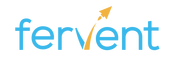
# Optimising Portfolio Weights - Achieving a Target Return
In this walkthrough, you'll explore how we can optimise our portfolio weights to achieve a target return.

### The return of a $k$ asset portfolio is calculated as...
$$r_p = \sum_{i=1}^kr_i\omega_i \equiv r_1\omega_1 + r_2\omega_2 + ... + r_k\omega_k$$  

Alternatively...  
$$r_p = \mathbf{\Omega'R}$$

Where:  
$r_p = $ Return on a portfolio  
$r_i = $ Return on a stock $i$  
$\omega_i = $ The weight or proportion invested in stock $i$  
$\mathbf{\Omega} = $ Vector of weights  
$\mathbf{R} = $ Matrix of returns

In [1]:
# Import package dependencies
import pandas as pd
import numpy as np
from scipy.optimize import minimize

<div class="alert alert-block alert-info">
<b>Confused by the code below?</b>  

Go back to the lecture on Reducing Risk by Diversification to understand the code in `In[2]` and `In[4]` before moving on any further.
</div>


In [2]:
df = pd.read_csv('../data/15stocks_price.csv')
df.set_index('date_gsheets', inplace=True)

In [3]:
df.head()

,AAPL,KO,NFLX,BRK.B,DIS,IBM,VZ,WMT,GE,TSLA,MA,AMZN,MSFT,UN,V
date_gsheets,,,,,,,,,,,,,,,
01/03/2012 16:00,58.75,35.07,10.32,77.68,38.31,186.30,39.73,60.33,18.36,28.08,36.84,179.03,26.77,34.92,25.75
01/04/2012 16:00,59.06,34.85,11.49,76.80,38.85,185.54,39.21,59.71,18.56,27.71,35.63,177.51,27.40,34.45,25.29
01/05/2012 16:00,59.72,34.69,11.33,76.93,39.50,184.66,38.94,59.42,18.55,27.12,35.24,177.61,27.68,34.49,25.48
01/06/2012 16:00,60.34,34.47,12.33,76.39,39.91,182.54,38.33,59.00,18.65,26.91,34.29,182.61,28.11,33.27,25.18
01/09/2012 16:00,60.25,34.47,14.03,76.29,39.75,181.59,38.37,59.18,18.86,27.25,34.58,178.56,27.74,33.72,24.98


In [4]:
returns_df = df.pct_change(1).dropna()

In [5]:
returns_df.head()

,AAPL,KO,NFLX,BRK.B,DIS,IBM,VZ,WMT,GE,TSLA,MA,AMZN,MSFT,UN,V
date_gsheets,,,,,,,,,,,,,,,
01/04/2012 16:00,0.005277,-0.006273,0.113372,-0.011329,0.014096,-0.004079,-0.013088,-0.010277,0.010893,-0.013177,-0.032845,-0.008490,0.023534,-0.013459,-0.017864
01/05/2012 16:00,0.011175,-0.004591,-0.013925,0.001693,0.016731,-0.004743,-0.006886,-0.004857,-0.000539,-0.021292,-0.010946,0.000563,0.010219,0.001161,0.007513
01/06/2012 16:00,0.010382,-0.006342,0.088261,-0.007019,0.010380,-0.011481,-0.015665,-0.007068,0.005391,-0.007743,-0.026958,0.028152,0.015535,-0.035373,-0.011774
01/09/2012 16:00,-0.001492,0.000000,0.137875,-0.001309,-0.004009,-0.005204,0.001044,0.003051,0.011260,0.012635,0.008457,-0.022178,-0.013163,0.013526,-0.007943
01/10/2012 16:00,0.003485,0.005802,-0.024234,0.014812,-0.003019,-0.001542,0.005212,-0.002366,-0.007423,0.013578,0.008676,0.004368,0.003605,0.005635,-0.001201


In [6]:
returns_df.mean()

AAPL     0.000825
KO       0.000216
NFLX     0.002453
BRK.B    0.000661
DIS      0.000750
IBM     -0.000062
VZ       0.000242
WMT      0.000384
GE       0.000034
TSLA     0.002057
MA       0.001020
AMZN     0.001416
MSFT     0.000868
UN       0.000388
V        0.001068
dtype: float64

## Creating the Objective Function

In [7]:
def getPortReturn(weights):
    """
    Returns the Annualised Expected Return of a portfolio.
    Annualises the return using the 'crude' method.
    """
    exp_ret_portfolio = np.dot(np.transpose(weights), returns_df.mean()) * 250
    
    return exp_ret_portfolio

In [8]:
# Create a vector of equal weights as the initial (init) guess
num_stocks = len(returns_df.columns)
init_weights = [1 / num_stocks] * num_stocks

In [9]:
# Calculate the expected return on the portfolio of equal weights
getPortReturn(init_weights)

0.20535127905081593

In [10]:
# Set a target return (note: the lecture starts with a target_return = 0.3)
target_return = 0.4

## Setting up constraints
### We need to create 2 + 1 constraints.  
#### The first 2 constraints
The first 2 constraints are identical to the constraints set up in the slides.  
That is, first, we have the constraint that the weight of any asset *i* must be between 0 and 1 inclusive. Second, we have the constraint that the sum of the weights must equate to 1.  

#### The 'additional' constraint
Finally, since we want the expected return on the portfolio to be equal to the target return, we can setup a constraint that the *difference between* the expected return on the portfolio and the target must be equal to 0.

### Creating the constraints
We can create the first constraint (that the weight of any asset must be between 0 and 1 inclusive) and pass it into the 'bounds' argument within SciPy's minimize method.  
The other 2 constraints can be created and passed into the 'constraints' argument within SciPy's minimize method.

In [11]:
# Create the constraint that the weight of any asset i must be between 0 and 1 inclusive.
bounds = tuple((0, 1) for i in range(num_stocks))

In [12]:
bounds

((0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1))

<div class="alert alert-block alert-info">
<h3>Understanding the constraints within `cons`</h3>  

Note that SciPy will optimise for the objective function, subject to the constraints.  
It will "know" it's satisfied the constraints if and only if the *function inside the constraint* returns 0.  

Thus, our constraints will be satisfied if the function within the 'fun' parameter in `cons` returns 0.  
<br>
Note that both constraints are "equality" constraints, meaning we're saying this constraint must be *equal to* something. This is why we set the "type" parameter as "eq" (where `eq =  equality`)


<h5>Sum of weights equate to 1</h5>
In the first case, we set up a constraint for the sum of the weights to equate to 1.  
Here, we use a `lambda` function (i.e., an 'anonymous' function: see documentation here: https://docs.python.org/3/tutorial/controlflow.html#lambda-expressions).  
<br>

Within the lambda function, `np.sum(w)` returns the sum of the weights, which we want to equate to 1.  
Remember that SciPy "knows" it's satisfied the constraints if and only if the *function inside the constraint* returns 0. Thus, if we subtract 1 from `np.sum(w)`, it will only be equal to 0 if the sum of the weights is equal to 1.

<h5>Expected Return on the Portfolio is equal to the Target</h5>
In the second dictionary, we setup a constraint for the expected return on the portfolio to be equal to the target.  
<br>
Remember that we're trying to <i>optimise weights</i> such that the expected return on the portfolio is equal to the target return. If the expected return on the portfolio is equal to the target return, then the difference between the expected return and the target return must be equal to 0.

<h4>Still confused?</h4>
Rewatch the video to fully understand this vital concept.
</div>


In [13]:
# Setup the other 2 constraints
cons = (
    # Sum of weights must equate to 1
    {'type' : 'eq', 'fun' : lambda w : np.sum(w) - 1},
    
    # Difference between expected return and target must be equal to 0.
    {'type' : 'eq', 'fun' : lambda x : x.dot(returns_df.mean()) * 250 - target_return})

In [14]:
results = minimize(fun=getPortReturn,  # being the objective function
                   x0=init_weights,  # being the initial guess
                   # bounds: being the constraint that the weight of any asset i
                   # must be between 0 and 1 inclusive
                   bounds=bounds,
                   constraints=cons)  # being the other 2 constraints (see 'cons' in In[13])

In [15]:
results

     fun: 0.39999999978614403
     jac: array([ 0.20626795,  0.05398266,  0.61322932,  0.16528047,  0.18761196,
       -0.01560373,  0.0603794 ,  0.09600191,  0.00856303,  0.51433236,
        0.2549938 ,  0.35404797,  0.2169628 ,  0.09711015,  0.26710914])
 message: 'Optimization terminated successfully.'
    nfev: 34
     nit: 2
    njev: 2
  status: 0
 success: True
       x: array([0.06011175, 0.        , 0.25594492, 0.04038823, 0.05113433,
       0.        , 0.        , 0.00705081, 0.        , 0.20835488,
       0.08355903, 0.13122471, 0.0652582 , 0.00758411, 0.08938903])

In [16]:
# Test the output by passing in the optimised weights into getPortReturn()
getPortReturn(weights=results['x'])

0.39999999978614403

In [17]:
# Store the optimised weights as a dataframe object
optimised_weights = pd.DataFrame(results['x'])

In [18]:
optimised_weights

,0
0,0.060112
1,0.000000
2,0.255945
3,0.040388
4,0.051134
5,0.000000
6,0.000000
7,0.007051
8,0.000000
9,0.208355


In [19]:
# Set the tickers as the index of `optimised_weights` by using the column names of `returns_df`.
optimised_weights.index = returns_df.columns

In [20]:
optimised_weights

,0
AAPL,0.060112
KO,0.000000
NFLX,0.255945
BRK.B,0.040388
DIS,0.051134
IBM,0.000000
VZ,0.000000
WMT,0.007051
GE,0.000000
TSLA,0.208355
